# 资本市场不同发展阶段下的风格因子有效性研究

本研究使用从iFinD下载的宽基指数、风格指数、行业指数和企业生命周期代理指数的日度开盘、收盘、最高、最低点位数据，以每周三作为观察点（若某指数周三没有有效价格，则使用该指数此前最新一个交易日），使用高开低收均价计算周度收益率，并相对沪深300计算周度超额收益。


# 1. 市场环境

本部分分析七个风格因子在不同市场环境下的表现，具体包括价值、成长、红利、低波、质量、规模、动量。核心问题是：不同牛市、熊市、震荡市，以及不同利率和波动环境中，哪些风格更容易跑赢沪深300。


## 1.1 初始化与函数准备

这部分可以略过不看

In [14]:
from __future__ import annotations

import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


PROJECT_ROOT = Path(".")
if not (PROJECT_ROOT / "data" / "raw" / "ifind").exists():
    PROJECT_ROOT = Path("..")
PROJECT_ROOT = PROJECT_ROOT.resolve()
RAW_IFIND_DIR = PROJECT_ROOT / "data" / "raw" / "ifind"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUTS_DIR / "figures"
WEEKLY_START = pd.Timestamp("2005-07-06")
WEEKS_PER_YEAR = 52


@dataclass(frozen=True)
class IndexSpec:
    series_id: str
    index_name: str
    code: str
    role: str
    factor_cn: str


BASE_INDEX_SPECS = [
    IndexSpec("hs300", "沪深300", "000300.SH", "benchmark", "宽基"),
    IndexSpec("csi_all", "中证全指", "000985.CSI", "market", "宽基"),
    IndexSpec("csi500", "中证500", "000905.SH", "style", "规模"),
    IndexSpec("value", "300价值", "000919.CSI", "style", "价值"),
    IndexSpec("growth", "300成长", "000918.CSI", "style", "成长"),
    IndexSpec("dividend", "中证红利", "000922.CSI", "style", "红利"),
    IndexSpec("low_vol", "300SNLV", "930846.CSI", "style", "低波"),
    IndexSpec("quality", "盈利质量", "930860.CSI", "style", "质量"),
    IndexSpec("momentum", "300动量", "H30260.CSI", "style", "动量"),
]

INDUSTRY_INDEX_SPECS = [
    IndexSpec("ind_energy", "300能源", "000908.CSI", "industry", "行业"),
    IndexSpec("ind_materials", "300原材料", "000909.CSI", "industry", "行业"),
    IndexSpec("ind_industrials", "300工业", "000910.CSI", "industry", "行业"),
    IndexSpec("ind_consumer_discretionary", "300可选消费", "000911.CSI", "industry", "行业"),
    IndexSpec("ind_consumer_staples", "300主要消费", "000912.CSI", "industry", "行业"),
    IndexSpec("ind_healthcare", "300医药卫生", "000913.SH", "industry", "行业"),
    IndexSpec("ind_information_technology", "300信息技术", "000915.CSI", "industry", "行业"),
    IndexSpec("ind_communication_services", "300通信服务", "000916.CSI", "industry", "行业"),
    IndexSpec("ind_utilities", "300公用事业", "000917.CSI", "industry", "行业"),
    IndexSpec("ind_real_estate", "300房地产", "000952.CSI", "industry", "行业"),
    IndexSpec("ind_financials", "300金融", "931821.CSI", "industry", "行业"),
]

LIFECYCLE_INDEX_SPECS = [
    IndexSpec("lc_startup", "北证50", "899050.BJ", "lifecycle", "初创期"),
    IndexSpec("lc_growth", "创业板50", "399673.SZ", "lifecycle", "成长期"),
    IndexSpec("lc_mature", "中证A50", "930050.CSI", "lifecycle", "成熟期"),
    IndexSpec("lc_adjustment", "上国改革", "H50052.CSI", "lifecycle", "调整期"),
]

INDEX_SPECS = BASE_INDEX_SPECS + INDUSTRY_INDEX_SPECS + LIFECYCLE_INDEX_SPECS
STYLE_ORDER = ["价值", "成长", "红利", "低波", "质量", "规模", "动量"]
CORE_STYLE_ORDER = ["价值", "成长", "红利", "低波", "质量", "动量"]
INDUSTRY_ORDER = [spec.index_name for spec in INDUSTRY_INDEX_SPECS]
LIFECYCLE_ORDER = ["初创期", "成长期", "成熟期", "调整期"]
LIFECYCLE_ANALYSIS_ORDER = [spec.factor_cn for spec in LIFECYCLE_INDEX_SPECS]
ROLE_CN = {
    "benchmark": "基准",
    "market": "市场",
    "style": "风格",
    "industry": "行业",
    "lifecycle": "企业生命周期",
}
COLUMN_CN = {
    "series_id": "序列编号",
    "index_name": "指数名称",
    "index_code": "指数代码",
    "role": "角色",
    "factor_cn": "风格因子",
    "source_file": "源文件",
    "index": "日期",
    "date": "日期",
    "open": "开盘价",
    "high": "最高价",
    "low": "最低价",
    "close": "收盘价",
    "trade_price": "交易均价",
    "cn_govt_10y_yield": "10年期国债收益率",
    "phase_id": "阶段编号",
    "phase_name": "阶段名称",
    "start": "开始日期",
    "end": "结束日期",
    "days": "日度观测数",
    "market_regime": "市场状态",
    "regime_detail": "阶段细分",
    "weeks": "周数",
    "start_price": "期初点位",
    "end_price": "期末点位",
    "total_return": "区间涨跌幅",
    "annualized_vol": "年化波动率",
    "max_drawdown": "最大回撤",
    "high_price": "区间最高点",
    "low_price": "区间最低点",
    "event_note": "阶段事件",
    "turn_id": "拐点编号",
    "turn_type": "拐点类型",
    "anchor_date": "锚点日期",
    "turn_date": "拐点日期",
    "turn_price": "拐点点位",
    "market_26w_return": "市场26周收益",
    "market_52w_return": "市场52周收益",
    "market_26w_vol": "市场26周年化波动率",
    "market_52w_max_drawdown": "市场52周最大回撤",
    "vol_env": "波动环境",
    "rate_13w_change_bp": "13周利率变化bp",
    "rate_26w_change_bp": "26周利率变化bp",
    "rate_env_13w": "利率方向",
    "rate_level_env": "利率水平",
    "style_index_name": "风格指数名称",
    "style_return": "风格收益",
    "hs300_return": "沪深300收益",
    "csi_all_return": "中证全指收益",
    "excess_vs_hs300": "相对沪深300超额收益",
    "excess_vs_csi_all": "相对中证全指超额收益",
    "primary_excess": "主口径超额收益",
    "missing_excess": "缺失超额收益周数",
    "environment_type": "环境维度",
    "environment_value": "环境分类",
    "style_ann_return": "风格年化收益",
    "hs300_ann_return": "沪深300年化收益",
    "ann_excess_mean": "年化超额收益",
    "cum_relative_excess": "累计相对超额收益",
    "information_ratio": "信息比率",
    "win_rate": "胜率",
    "style_max_drawdown": "风格最大回撤",
    "relative_max_drawdown": "相对最大回撤",
    "industry_name": "行业名称",
    "industry_code": "行业代码",
    "industry_return": "行业收益",
    "industry_excess": "行业超额收益",
    "lifecycle_stage": "企业生命周期阶段",
    "lifecycle_index_name": "生命周期代理指数",
    "lifecycle_code": "生命周期指数代码",
    "lifecycle_return": "生命周期代理收益",
    "lifecycle_excess": "生命周期代理超额收益",
    "coef_beta": "回归系数",
    "t_stat": "t值",
    "p_value": "p值",
    "nobs": "样本周数",
    "r_squared": "R方",
    "residual_ann_vol": "残差年化波动率",
    "beta_dispersion": "贝塔分化度",
    "avg_abs_t": "平均绝对t值",
    "significant_positive_industries": "显著正向行业数",
    "significant_negative_industries": "显著负向行业数",
    "high_beta_industries": "高贝塔行业",
    "low_beta_industries": "低贝塔行业",
    "significant_positive_lifecycle_stages": "显著正向生命周期阶段数",
    "significant_negative_lifecycle_stages": "显著负向生命周期阶段数",
    "high_beta_lifecycle_stages": "高贝塔生命周期阶段",
    "low_beta_lifecycle_stages": "低贝塔生命周期阶段",
    "high_minus_low_ann_return": "高低贝塔组合年化收益差",
    "high_minus_low_ir": "高低贝塔组合信息比率",
    "high_minus_low_win_rate": "高低贝塔组合胜率",
    "valid_weeks": "有效周数",
    "missing_weeks": "缺失周数",
}

REFERENCE_PHASES = [
    {
        "phase_id": 1,
        "anchor_start": "2005-07-01",
        "anchor_end": "2007-10-31",
        "phase_name": "股改后全面牛市",
        "direction": "上行",
        "event_note": "股权分置改革、企业盈利改善、居民资金入市",
    },
    {
        "phase_id": 2,
        "anchor_start": "2007-11-01",
        "anchor_end": "2008-10-31",
        "phase_name": "金融危机熊市",
        "direction": "下行",
        "event_note": "政策收紧、海外金融危机冲击、风险偏好急降",
    },
    {
        "phase_id": 3,
        "anchor_start": "2008-11-01",
        "anchor_end": "2010-03-31",
        "phase_name": "刺激政策修复",
        "direction": "上行",
        "event_note": "逆周期政策发力、基建地产链修复、顺周期资产反弹",
    },
    {
        "phase_id": 4,
        "anchor_start": "2010-04-01",
        "anchor_end": "2010-11-10",
        "phase_name": "地产调控震荡期",
        "direction": "上行",
        "window_weeks": 0,
        "event_note": "地产调控、市场先下后上、风险偏好反复",
    },
    {
        "phase_id": 5,
        "anchor_start": "2010-11-10",
        "anchor_end": "2012-11-30",
        "phase_name": "盈利下行熊市",
        "direction": "下行",
        "window_weeks": 4,
        "event_note": "经济增速放缓、盈利预期下修、风险偏好回落",
    },
    {
        "phase_id": 6,
        "anchor_start": "2012-11-30",
        "anchor_end": "2014-03-31",
        "phase_name": "低位修复震荡",
        "direction": "下行",
        "event_note": "政策托底、流动性边际改善、市场底部反复",
    },
    {
        "phase_id": 7,
        "anchor_start": "2014-04-01",
        "anchor_end": "2015-06-30",
        "phase_name": "杠杆资金与成长牛市",
        "direction": "上行",
        "event_note": "流动性宽松、互联网产业叙事、杠杆资金入市",
    },
    {
        "phase_id": 8,
        "anchor_start": "2015-07-01",
        "anchor_end": "2016-02-29",
        "phase_name": "去杠杆急跌",
        "direction": "下行",
        "event_note": "清理场外配资、市场去杠杆、风险偏好收缩",
    },
    {
        "phase_id": 9,
        "anchor_start": "2016-03-01",
        "anchor_end": "2018-01-31",
        "phase_name": "供给侧与核心资产阶段",
        "direction": "上行",
        "event_note": "供给侧改革、盈利修复、核心资产重估",
    },
    {
        "phase_id": 10,
        "anchor_start": "2018-02-01",
        "anchor_end": "2018-12-31",
        "phase_name": "贸易摩擦熊市",
        "direction": "下行",
        "event_note": "金融去杠杆余波、信用风险、中美贸易摩擦",
    },
    {
        "phase_id": 11,
        "anchor_start": "2019-01-01",
        "anchor_end": "2019-04-30",
        "phase_name": "政策修复反弹",
        "direction": "上行",
        "event_note": "政策预期改善、外资流入、风险偏好修复",
    },
    {
        "phase_id": 12,
        "anchor_start": "2019-05-01",
        "anchor_end": "2020-03-31",
        "phase_name": "疫情前后震荡",
        "direction": "下行",
        "event_note": "贸易摩擦反复、疫情冲击、盈利预期下修",
    },
    {
        "phase_id": 13,
        "anchor_start": "2020-04-01",
        "anchor_end": "2021-12-31",
        "phase_name": "流动性与产业牛市",
        "direction": "上行",
        "event_note": "经济修复、货币环境宽松、产业政策支持",
    },
    {
        "phase_id": 14,
        "anchor_start": "2022-01-01",
        "anchor_end": "2024-08-31",
        "phase_name": "地产压力与红利占优",
        "direction": "下行",
        "event_note": "地产压力、疫情扰动、低利率下高分红资产重估",
    },
    {
        "phase_id": 15,
        "anchor_start": "2024-09-01",
        "anchor_end": None,
        "phase_name": "政策转向修复观察",
        "direction": "上行",
        "event_note": "政策转向、风险偏好修复、科技与稳增长并行",
    },
]




In [15]:
def setup_chinese_fonts() -> None:
    plt.rcParams["font.sans-serif"] = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Arial Unicode MS",
        "DejaVu Sans",
    ]
    plt.rcParams["axes.unicode_minus"] = False


def ensure_dirs() -> None:
    for directory in [PROCESSED_DIR, OUTPUTS_DIR, FIGURE_DIR]:
        directory.mkdir(parents=True, exist_ok=True)


def chinese_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "role" in out.columns:
        out["role"] = out["role"].map(ROLE_CN).fillna(out["role"])
    return out.rename(columns=COLUMN_CN)


def save_chinese_csv(df: pd.DataFrame, path: Path, index: bool = False) -> None:
    export = df.reset_index() if index else df.copy()
    chinese_table(export).to_csv(path, index=False, encoding="utf-8-sig")


def find_index_file(code: str) -> Path:
    matches = sorted([p for p in RAW_IFIND_DIR.glob(f"*{code}*.xlsx") if not p.name.startswith("~$")])
    if not matches:
        raise FileNotFoundError(f"未找到包含 {code} 的 Excel 文件")
    if len(matches) > 1:
        names = [p.name for p in matches]
        raise FileExistsError(f"{code} 匹配到多个文件: {names}")
    return matches[0]


def find_rate_file() -> Path:
    matches = sorted(
        [
            p
            for p in RAW_IFIND_DIR.glob("*.xlsx")
            if "10" in p.name and "历史价格" not in p.name and not p.name.startswith("~$")
        ]
    )
    if not matches:
        raise FileNotFoundError("未找到 10 年期国债收益率 Excel 文件")
    if len(matches) > 1:
        names = [p.name for p in matches]
        raise FileExistsError(f"10 年期国债收益率匹配到多个文件: {names}")
    return matches[0]


def read_index_excel(spec: IndexSpec) -> pd.DataFrame:
    path = find_index_file(spec.code)
    df = pd.read_excel(path)
    if df.shape[1] < 5:
        raise ValueError(f"{path.name} 至少需要日期、开盘、最高、最低、收盘五列")

    work = df.iloc[:, :5].copy()
    work.columns = ["date", "open", "high", "low", "close"]
    work["date"] = pd.to_datetime(work["date"], errors="coerce")
    for col in ["open", "high", "low", "close"]:
        work[col] = pd.to_numeric(work[col], errors="coerce")
    work = work.dropna(subset=["date", "open", "high", "low", "close"])
    work = work.sort_values("date").drop_duplicates("date", keep="last")
    work["trade_price"] = work[["open", "high", "low", "close"]].mean(axis=1)
    work.insert(0, "factor_cn", spec.factor_cn)
    work.insert(0, "role", spec.role)
    work.insert(0, "index_code", spec.code)
    work.insert(0, "index_name", spec.index_name)
    work.insert(0, "series_id", spec.series_id)
    work["source_file"] = path.name
    return work


def read_rate_excel() -> pd.DataFrame:
    path = find_rate_file()
    df = pd.read_excel(path)
    if df.shape[1] < 2:
        raise ValueError(f"{path.name} 至少需要日期和收益率两列")
    work = df.iloc[:, :2].copy()
    work.columns = ["date", "cn_govt_10y_yield"]
    work["date"] = pd.to_datetime(work["date"], errors="coerce")
    work["cn_govt_10y_yield"] = pd.to_numeric(work["cn_govt_10y_yield"], errors="coerce")
    return work.dropna().sort_values("date").drop_duplicates("date", keep="last")


def build_weekly_prices(daily_long: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    daily_price_wide = daily_long.pivot(index="date", columns="index_name", values="trade_price").sort_index()
    weekly_dates = pd.date_range(WEEKLY_START, daily_long["date"].max(), freq="W-WED")
    aligned_dates = daily_price_wide.index.union(weekly_dates).sort_values()
    ordered_columns = [spec.index_name for spec in INDEX_SPECS if spec.index_name in daily_price_wide.columns]
    weekly_price_wide = (
        daily_price_wide.reindex(aligned_dates)
        .ffill()
        .reindex(weekly_dates)
        .reindex(columns=ordered_columns)
    )
    weekly_return_wide = weekly_price_wide.pct_change(fill_method=None)
    metadata_cols = ["series_id", "index_name", "index_code", "role", "factor_cn", "source_file"]
    metadata = daily_long.sort_values("date").drop_duplicates("index_name", keep="last")[metadata_cols]
    weekly_long = (
        weekly_price_wide.reset_index(names="date")
        .melt(id_vars="date", var_name="index_name", value_name="trade_price")
        .merge(metadata, on="index_name", how="left")
        .sort_values(["series_id", "date"])
        .reset_index(drop=True)
    )
    return weekly_long, weekly_price_wide, weekly_return_wide




In [16]:
def max_drawdown(return_series: pd.Series) -> float:
    ret = return_series.dropna()
    if ret.empty:
        return np.nan
    wealth = (1 + ret).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    return float(drawdown.min())


def annualized_return(return_series: pd.Series) -> float:
    ret = return_series.dropna()
    if ret.empty:
        return np.nan
    return float((1 + ret).prod() ** (WEEKS_PER_YEAR / len(ret)) - 1)


def information_ratio(excess_series: pd.Series) -> float:
    ex = excess_series.dropna()
    if len(ex) < 3 or ex.std(ddof=1) == 0:
        return np.nan
    return float(ex.mean() / ex.std(ddof=1) * math.sqrt(WEEKS_PER_YEAR))


def normal_two_sided_p_value(t_stat: float) -> float:
    if pd.isna(t_stat):
        return np.nan
    return float(math.erfc(abs(float(t_stat)) / math.sqrt(2)))


def local_extreme_date(
    price: pd.Series,
    anchor_date: pd.Timestamp,
    kind: str,
    window_weeks: int = 18,
    lower_bound: pd.Timestamp | None = None,
) -> pd.Timestamp:
    start = anchor_date - pd.Timedelta(weeks=window_weeks)
    end = anchor_date + pd.Timedelta(weeks=window_weeks)
    if lower_bound is not None:
        start = max(start, lower_bound)
    window = price[(price.index >= start) & (price.index <= end)].dropna()
    if window.empty:
        later = price[price.index >= start]
        window = later.head(1) if not later.empty else price.tail(1)
    return window.idxmax() if kind == "high" else window.idxmin()


def classify_market_regime(total_return: float, annualized_vol: float, mdd: float) -> tuple[str, str]:
    if pd.isna(total_return):
        return "未覆盖", "未覆盖"
    if total_return >= 0.20:
        return "牛市", "显著上行"
    if total_return <= -0.20:
        return "熊市", "显著下行"
    if total_return >= 0.08:
        return "震荡市", "震荡上行"
    if total_return <= -0.08:
        return "震荡市", "震荡下行"
    if annualized_vol >= 0.25 or mdd <= -0.18:
        return "震荡市", "高波动震荡"
    return "震荡市", "窄幅震荡"


def build_market_phase_table(weekly_price_wide: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    market = weekly_price_wide["中证全指"].dropna()
    market_ret = market.pct_change()

    turn_rows = [
        {
            "turn_id": 0,
            "turn_type": "起点",
            "anchor_date": market.index.min().date().isoformat(),
            "turn_date": market.index.min(),
            "turn_price": float(market.iloc[0]),
        }
    ]
    previous_turn = market.index.min()
    for phase in REFERENCE_PHASES[:-1]:
        anchor = pd.Timestamp(phase["anchor_end"])
        kind = "high" if phase["direction"] == "上行" else "low"
        turn_date = local_extreme_date(
            market,
            anchor,
            kind,
            window_weeks=phase.get("window_weeks", 18),
            lower_bound=previous_turn + pd.Timedelta(days=7),
        )
        turn_rows.append(
            {
                "turn_id": phase["phase_id"],
                "turn_type": "局部高点" if kind == "high" else "局部低点",
                "anchor_date": anchor.date().isoformat(),
                "turn_date": turn_date,
                "turn_price": float(market.loc[turn_date]),
            }
        )
        previous_turn = turn_date

    turn_rows.append(
        {
            "turn_id": len(REFERENCE_PHASES),
            "turn_type": "最新观察",
            "anchor_date": market.index.max().date().isoformat(),
            "turn_date": market.index.max(),
            "turn_price": float(market.iloc[-1]),
        }
    )
    turning_points = pd.DataFrame(turn_rows)

    phase_rows = []
    for idx, phase in enumerate(REFERENCE_PHASES):
        start_date = pd.Timestamp(turning_points.loc[idx, "turn_date"])
        end_date = pd.Timestamp(turning_points.loc[idx + 1, "turn_date"])
        seg_price = market[(market.index >= start_date) & (market.index <= end_date)]
        seg_ret = market_ret[(market_ret.index > start_date) & (market_ret.index <= end_date)]
        start_price = float(market.loc[start_date])
        end_price = float(market.loc[end_date])
        total_return = end_price / start_price - 1
        annualized_vol = float(seg_ret.std(ddof=1) * math.sqrt(WEEKS_PER_YEAR)) if len(seg_ret) > 1 else np.nan
        mdd = max_drawdown(seg_ret)
        market_regime, regime_detail = classify_market_regime(total_return, annualized_vol, mdd)
        phase_rows.append(
            {
                "phase_id": phase["phase_id"],
                "phase_name": phase["phase_name"],
                "start": start_date.date().isoformat(),
                "end": end_date.date().isoformat(),
                "market_regime": market_regime,
                "regime_detail": regime_detail,
                "weeks": int(len(seg_ret)),
                "start_price": start_price,
                "end_price": end_price,
                "total_return": total_return,
                "annualized_vol": annualized_vol,
                "max_drawdown": mdd,
                "high_price": float(seg_price.max()),
                "low_price": float(seg_price.min()),
                "event_note": phase["event_note"],
            }
        )
    return pd.DataFrame(phase_rows), turning_points


def assign_market_phase(dates: pd.Index, phase_df: pd.DataFrame) -> pd.DataFrame:
    env = pd.DataFrame({"date": pd.to_datetime(dates)})
    env["phase_id"] = np.nan
    env["phase_name"] = ""
    env["market_regime"] = ""
    env["regime_detail"] = ""
    env["event_note"] = ""
    for i, row in phase_df.iterrows():
        start = pd.Timestamp(row["start"])
        end = pd.Timestamp(row["end"])
        if i == 0:
            mask = (env["date"] >= start) & (env["date"] <= end)
        else:
            mask = (env["date"] > start) & (env["date"] <= end)
        env.loc[mask, "phase_id"] = row["phase_id"]
        env.loc[mask, "phase_name"] = row["phase_name"]
        env.loc[mask, "market_regime"] = row["market_regime"]
        env.loc[mask, "regime_detail"] = row["regime_detail"]
        env.loc[mask, "event_note"] = row["event_note"]
    return env


def label_quantile_env(
    series: pd.Series,
    low_q: float,
    high_q: float,
    low_label: str,
    mid_label: str,
    high_label: str,
) -> pd.Series:
    labels = pd.Series(index=series.index, dtype="object")
    valid = series.dropna()
    if valid.empty:
        return labels
    low_bar = valid.quantile(low_q)
    high_bar = valid.quantile(high_q)
    labels.loc[series <= low_bar] = low_label
    labels.loc[(series > low_bar) & (series < high_bar)] = mid_label
    labels.loc[series >= high_bar] = high_label
    return labels




In [17]:
def build_environment_table(
    weekly_price_wide: pd.DataFrame,
    weekly_return_wide: pd.DataFrame,
    rate_daily: pd.DataFrame,
    phase_df: pd.DataFrame,
) -> pd.DataFrame:
    env = assign_market_phase(weekly_price_wide.index, phase_df).set_index("date").sort_index()
    market_ret = weekly_return_wide["中证全指"]
    env["market_26w_return"] = weekly_price_wide["中证全指"].pct_change(26)
    env["market_52w_return"] = weekly_price_wide["中证全指"].pct_change(52)
    env["market_26w_vol"] = market_ret.rolling(26).std() * math.sqrt(WEEKS_PER_YEAR)
    env["market_52w_max_drawdown"] = market_ret.rolling(52).apply(lambda x: max_drawdown(pd.Series(x)), raw=False)
    env["vol_env"] = label_quantile_env(env["market_26w_vol"], 0.30, 0.70, "低波动", "中波动", "高波动")

    rate_weekly = rate_daily[rate_daily["date"].dt.weekday == 2].copy()
    rate_weekly = rate_weekly[rate_weekly["date"] >= WEEKLY_START].set_index("date").sort_index()
    env = env.join(rate_weekly[["cn_govt_10y_yield"]], how="left")
    env["cn_govt_10y_yield"] = env["cn_govt_10y_yield"].ffill()
    env["rate_13w_change_bp"] = (env["cn_govt_10y_yield"] - env["cn_govt_10y_yield"].shift(13)) * 100
    env["rate_26w_change_bp"] = (env["cn_govt_10y_yield"] - env["cn_govt_10y_yield"].shift(26)) * 100
    env["rate_env_13w"] = np.select(
        [env["rate_13w_change_bp"] > 10, env["rate_13w_change_bp"] < -10],
        ["利率上行", "利率下行"],
        default="利率震荡",
    )
    env.loc[env["rate_13w_change_bp"].isna(), "rate_env_13w"] = np.nan
    env["rate_level_env"] = label_quantile_env(env["cn_govt_10y_yield"], 0.30, 0.70, "低利率", "中利率", "高利率")
    return env.reset_index()


def build_style_panel(weekly_return_wide: pd.DataFrame, env_table: pd.DataFrame) -> pd.DataFrame:
    style_name_map = {
        "价值": "300价值",
        "成长": "300成长",
        "红利": "中证红利",
        "低波": "300SNLV",
        "质量": "盈利质量",
        "规模": "中证500",
        "动量": "300动量",
    }
    env = env_table.set_index("date")
    rows = []
    for factor_cn, index_name in style_name_map.items():
        tmp = pd.DataFrame(index=weekly_return_wide.index)
        tmp["factor_cn"] = factor_cn
        tmp["style_index_name"] = index_name
        tmp["style_return"] = weekly_return_wide[index_name]
        tmp["hs300_return"] = weekly_return_wide["沪深300"]
        tmp["csi_all_return"] = weekly_return_wide["中证全指"]
        tmp["excess_vs_hs300"] = tmp["style_return"] - tmp["hs300_return"]
        tmp["excess_vs_csi_all"] = tmp["style_return"] - tmp["csi_all_return"]
        tmp["primary_excess"] = tmp["excess_vs_hs300"]
        tmp = tmp.join(env, how="left")
        rows.append(tmp.reset_index().rename(columns={"index": "date"}))
    panel = pd.concat(rows, ignore_index=True)
    panel["factor_cn"] = pd.Categorical(panel["factor_cn"], categories=STYLE_ORDER, ordered=True)
    return panel.sort_values(["date", "factor_cn"]).reset_index(drop=True)


def perf_stats(group: pd.DataFrame, env_type: str, env_value: str, factor_cn: str) -> dict[str, object]:
    data = group.dropna(subset=["style_return", "hs300_return", "primary_excess"])
    if data.empty:
        return {"environment_type": env_type, "environment_value": env_value, "factor_cn": factor_cn, "weeks": 0}
    relative_curve = (1 + data["style_return"]).cumprod() / (1 + data["hs300_return"]).cumprod()
    relative_drawdown = relative_curve / relative_curve.cummax() - 1
    return {
        "environment_type": env_type,
        "environment_value": env_value,
        "factor_cn": factor_cn,
        "weeks": int(len(data)),
        "style_ann_return": annualized_return(data["style_return"]),
        "hs300_ann_return": annualized_return(data["hs300_return"]),
        "ann_excess_mean": data["primary_excess"].mean() * WEEKS_PER_YEAR,
        "cum_relative_excess": float(relative_curve.iloc[-1] - 1),
        "information_ratio": information_ratio(data["primary_excess"]),
        "win_rate": float((data["primary_excess"] > 0).mean()),
        "style_max_drawdown": max_drawdown(data["style_return"]),
        "relative_max_drawdown": float(relative_drawdown.min()),
    }


def build_environment_summary(panel: pd.DataFrame) -> pd.DataFrame:
    env_columns = {
        "市场状态": "market_regime",
        "历史阶段": "phase_name",
        "波动环境": "vol_env",
        "利率方向": "rate_env_13w",
        "利率水平": "rate_level_env",
    }
    rows = []
    for env_type, col in env_columns.items():
        valid = panel.dropna(subset=[col])
        for (env_value, factor_cn), group in valid.groupby([col, "factor_cn"], observed=False):
            rows.append(perf_stats(group, env_type, env_value, str(factor_cn)))
    return pd.DataFrame(rows)


def ols_with_tstats(y: pd.Series, x: pd.DataFrame) -> pd.DataFrame:
    data = pd.concat([y.rename("y"), x], axis=1).dropna()
    if len(data) <= x.shape[1] + 2:
        return pd.DataFrame()
    yv = data["y"].to_numpy(dtype=float)
    xv = data.drop(columns=["y"]).to_numpy(dtype=float)
    beta = np.linalg.pinv(xv.T @ xv) @ xv.T @ yv
    resid = yv - xv @ beta
    dof = max(len(yv) - xv.shape[1], 1)
    sigma2 = float((resid @ resid) / dof)
    cov = sigma2 * np.linalg.pinv(xv.T @ xv)
    se = np.sqrt(np.diag(cov))
    t_stats = np.divide(beta, se, out=np.full_like(beta, np.nan), where=se != 0)
    p_values = [normal_two_sided_p_value(t_stat) for t_stat in t_stats]
    total_var = np.sum((yv - yv.mean()) ** 2)
    r_squared = 1 - float((resid @ resid) / total_var) if total_var else np.nan
    residual_ann_vol = float(np.sqrt(sigma2) * math.sqrt(WEEKS_PER_YEAR))
    return pd.DataFrame(
        {
            "variable": data.drop(columns=["y"]).columns,
            "coef_weekly": beta,
            "coef_annualized": beta * WEEKS_PER_YEAR,
            "t_stat": t_stats,
            "p_value": p_values,
            "nobs": len(data),
            "r_squared": r_squared,
            "residual_ann_vol": residual_ann_vol,
        }
    )


def build_industry_panel(weekly_return_wide: pd.DataFrame, env_table: pd.DataFrame) -> pd.DataFrame:
    env = env_table.set_index("date")
    rows = []
    for spec in INDUSTRY_INDEX_SPECS:
        if spec.index_name not in weekly_return_wide.columns:
            continue
        tmp = pd.DataFrame(index=weekly_return_wide.index)
        tmp["industry_name"] = spec.index_name
        tmp["industry_code"] = spec.code
        tmp["industry_return"] = weekly_return_wide[spec.index_name]
        tmp["hs300_return"] = weekly_return_wide["沪深300"]
        tmp["industry_excess"] = tmp["industry_return"] - tmp["hs300_return"]
        tmp = tmp.join(env, how="left")
        rows.append(tmp.reset_index().rename(columns={"index": "date"}))
    panel = pd.concat(rows, ignore_index=True)
    panel["industry_name"] = pd.Categorical(panel["industry_name"], categories=INDUSTRY_ORDER, ordered=True)
    return panel.sort_values(["date", "industry_name"]).reset_index(drop=True)


def build_industry_style_regression(industry_panel: pd.DataFrame, style_panel: pd.DataFrame) -> pd.DataFrame:
    style_wide = (
        style_panel.pivot(index="date", columns="factor_cn", values="primary_excess")
        .reindex(columns=CORE_STYLE_ORDER)
        .sort_index()
    )
    industry_wide = (
        industry_panel.pivot(index="date", columns="industry_name", values="industry_excess")
        .reindex(columns=INDUSTRY_ORDER)
        .sort_index()
    )

    rows = []
    for industry_name in industry_wide.columns:
        x = pd.DataFrame(index=style_wide.index)
        x["const"] = 1.0
        x = x.join(style_wide)
        result = ols_with_tstats(industry_wide[industry_name], x)
        if result.empty:
            continue
        result = result[result["variable"] != "const"].copy()
        result["industry_name"] = industry_name
        result = result.rename(columns={"variable": "factor_cn", "coef_weekly": "coef_beta"})
        rows.append(
            result[
                [
                    "industry_name",
                    "factor_cn",
                    "coef_beta",
                    "t_stat",
                    "p_value",
                    "nobs",
                    "r_squared",
                    "residual_ann_vol",
                ]
            ]
        )
    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not out.empty:
        out["industry_name"] = pd.Categorical(out["industry_name"], categories=INDUSTRY_ORDER, ordered=True)
        out["factor_cn"] = pd.Categorical(out["factor_cn"], categories=CORE_STYLE_ORDER, ordered=True)
        out = out.sort_values(["industry_name", "factor_cn"]).reset_index(drop=True)
    return out


def build_industry_factor_effectiveness(
    industry_panel: pd.DataFrame,
    industry_regression: pd.DataFrame,
    top_n: int = 3,
) -> pd.DataFrame:
    industry_wide = (
        industry_panel.pivot(index="date", columns="industry_name", values="industry_excess")
        .reindex(columns=INDUSTRY_ORDER)
        .sort_index()
    )
    rows = []
    for factor in CORE_STYLE_ORDER:
        reg = industry_regression[industry_regression["factor_cn"] == factor].dropna(subset=["coef_beta"])
        if reg.empty:
            continue
        beta = reg.set_index("industry_name")["coef_beta"].sort_values()
        low_industries = beta.head(top_n).index.tolist()
        high_industries = beta.tail(top_n).index.tolist()
        high_return = industry_wide[high_industries].mean(axis=1)
        low_return = industry_wide[low_industries].mean(axis=1)
        spread = (high_return - low_return).dropna()
        significant_positive = int(((reg["coef_beta"] > 0) & (reg["p_value"] < 0.05)).sum())
        significant_negative = int(((reg["coef_beta"] < 0) & (reg["p_value"] < 0.05)).sum())
        rows.append(
            {
                "factor_cn": factor,
                "beta_dispersion": float(reg["coef_beta"].std(ddof=1)),
                "avg_abs_t": float(reg["t_stat"].abs().mean()),
                "significant_positive_industries": significant_positive,
                "significant_negative_industries": significant_negative,
                "high_beta_industries": "、".join(high_industries),
                "low_beta_industries": "、".join(low_industries),
                "high_minus_low_ann_return": spread.mean() * WEEKS_PER_YEAR if len(spread) else np.nan,
                "high_minus_low_ir": information_ratio(spread),
                "high_minus_low_win_rate": float((spread > 0).mean()) if len(spread) else np.nan,
                "valid_weeks": int(spread.notna().sum()),
            }
        )
    return pd.DataFrame(rows)


def build_lifecycle_panel(weekly_return_wide: pd.DataFrame, env_table: pd.DataFrame) -> pd.DataFrame:
    env = env_table.set_index("date")
    rows = []
    for spec in LIFECYCLE_INDEX_SPECS:
        if spec.index_name not in weekly_return_wide.columns:
            continue
        tmp = pd.DataFrame(index=weekly_return_wide.index)
        tmp["lifecycle_stage"] = spec.factor_cn
        tmp["lifecycle_index_name"] = spec.index_name
        tmp["lifecycle_code"] = spec.code
        tmp["lifecycle_return"] = weekly_return_wide[spec.index_name]
        tmp["hs300_return"] = weekly_return_wide["沪深300"]
        tmp["lifecycle_excess"] = tmp["lifecycle_return"] - tmp["hs300_return"]
        tmp = tmp.join(env, how="left")
        rows.append(tmp.reset_index().rename(columns={"index": "date"}))
    panel = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not panel.empty:
        panel["lifecycle_stage"] = pd.Categorical(panel["lifecycle_stage"], categories=LIFECYCLE_ORDER, ordered=True)
        panel = panel.sort_values(["date", "lifecycle_stage"]).reset_index(drop=True)
    return panel


def build_lifecycle_style_regression(lifecycle_panel: pd.DataFrame, style_panel: pd.DataFrame) -> pd.DataFrame:
    if lifecycle_panel.empty:
        return pd.DataFrame()
    style_wide = (
        style_panel.pivot(index="date", columns="factor_cn", values="primary_excess")
        .reindex(columns=CORE_STYLE_ORDER)
        .sort_index()
    )
    lifecycle_wide = (
        lifecycle_panel.pivot(index="date", columns="lifecycle_stage", values="lifecycle_excess")
        .reindex(columns=LIFECYCLE_ANALYSIS_ORDER)
        .sort_index()
    )

    rows = []
    for lifecycle_stage in lifecycle_wide.columns:
        x = pd.DataFrame(index=style_wide.index)
        x["const"] = 1.0
        x = x.join(style_wide)
        result = ols_with_tstats(lifecycle_wide[lifecycle_stage], x)
        if result.empty:
            continue
        result = result[result["variable"] != "const"].copy()
        result["lifecycle_stage"] = lifecycle_stage
        result = result.rename(columns={"variable": "factor_cn", "coef_weekly": "coef_beta"})
        rows.append(
            result[
                [
                    "lifecycle_stage",
                    "factor_cn",
                    "coef_beta",
                    "t_stat",
                    "p_value",
                    "nobs",
                    "r_squared",
                    "residual_ann_vol",
                ]
            ]
        )
    out = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not out.empty:
        out["lifecycle_stage"] = pd.Categorical(out["lifecycle_stage"], categories=LIFECYCLE_ORDER, ordered=True)
        out["factor_cn"] = pd.Categorical(out["factor_cn"], categories=CORE_STYLE_ORDER, ordered=True)
        out = out.sort_values(["lifecycle_stage", "factor_cn"]).reset_index(drop=True)
    return out


def build_lifecycle_factor_effectiveness(
    lifecycle_panel: pd.DataFrame,
    lifecycle_regression: pd.DataFrame,
    top_n: int = 1,
) -> pd.DataFrame:
    if lifecycle_panel.empty or lifecycle_regression.empty:
        return pd.DataFrame()
    lifecycle_wide = (
        lifecycle_panel.pivot(index="date", columns="lifecycle_stage", values="lifecycle_excess")
        .reindex(columns=LIFECYCLE_ANALYSIS_ORDER)
        .sort_index()
    )
    rows = []
    for factor in CORE_STYLE_ORDER:
        reg = lifecycle_regression[lifecycle_regression["factor_cn"] == factor].dropna(subset=["coef_beta"])
        if reg.empty:
            continue
        beta = reg.set_index("lifecycle_stage")["coef_beta"].sort_values()
        low_stages = beta.head(top_n).index.tolist()
        high_stages = beta.tail(top_n).index.tolist()
        high_return = lifecycle_wide[high_stages].mean(axis=1)
        low_return = lifecycle_wide[low_stages].mean(axis=1)
        spread = (high_return - low_return).dropna()
        significant_positive = int(((reg["coef_beta"] > 0) & (reg["p_value"] < 0.05)).sum())
        significant_negative = int(((reg["coef_beta"] < 0) & (reg["p_value"] < 0.05)).sum())
        rows.append(
            {
                "factor_cn": factor,
                "beta_dispersion": float(reg["coef_beta"].std(ddof=1)),
                "avg_abs_t": float(reg["t_stat"].abs().mean()),
                "significant_positive_lifecycle_stages": significant_positive,
                "significant_negative_lifecycle_stages": significant_negative,
                "high_beta_lifecycle_stages": "、".join(high_stages),
                "low_beta_lifecycle_stages": "、".join(low_stages),
                "high_minus_low_ann_return": spread.mean() * WEEKS_PER_YEAR if len(spread) else np.nan,
                "high_minus_low_ir": information_ratio(spread),
                "high_minus_low_win_rate": float((spread > 0).mean()) if len(spread) else np.nan,
                "valid_weeks": int(spread.notna().sum()),
            }
        )
    return pd.DataFrame(rows)




In [18]:
def save_core_tables(
    daily_long: pd.DataFrame,
    rate_daily: pd.DataFrame,
    weekly_long: pd.DataFrame,
    weekly_price_wide: pd.DataFrame,
    weekly_return_wide: pd.DataFrame,
    phase_df: pd.DataFrame,
    turning_points: pd.DataFrame,
    env_table: pd.DataFrame,
    panel: pd.DataFrame,
    summary: pd.DataFrame,
    industry_panel: pd.DataFrame,
    industry_regression: pd.DataFrame,
    industry_effectiveness: pd.DataFrame,
    lifecycle_panel: pd.DataFrame,
    lifecycle_regression: pd.DataFrame,
    lifecycle_effectiveness: pd.DataFrame,
) -> None:
    save_chinese_csv(daily_long, PROCESSED_DIR / "ifind_daily_index_prices_long.csv")
    save_chinese_csv(rate_daily, PROCESSED_DIR / "ifind_daily_10y_yield.csv")
    save_chinese_csv(weekly_long, PROCESSED_DIR / "weekly_index_prices_long.csv")
    save_chinese_csv(weekly_price_wide, PROCESSED_DIR / "weekly_index_prices_wide.csv", index=True)
    save_chinese_csv(weekly_return_wide, PROCESSED_DIR / "weekly_index_returns_wide.csv", index=True)
    save_chinese_csv(phase_df, OUTPUTS_DIR / "market_regime_phases.csv")
    save_chinese_csv(turning_points, OUTPUTS_DIR / "market_turning_points.csv")
    save_chinese_csv(env_table, OUTPUTS_DIR / "weekly_market_rate_environment.csv")
    save_chinese_csv(panel, OUTPUTS_DIR / "weekly_style_factor_panel.csv")
    save_chinese_csv(summary, OUTPUTS_DIR / "style_environment_summary.csv")
    save_chinese_csv(industry_panel, OUTPUTS_DIR / "weekly_industry_factor_panel.csv")
    save_chinese_csv(industry_regression, OUTPUTS_DIR / "industry_style_regression.csv")
    save_chinese_csv(industry_effectiveness, OUTPUTS_DIR / "industry_factor_effectiveness.csv")
    save_chinese_csv(lifecycle_panel, OUTPUTS_DIR / "weekly_lifecycle_factor_panel.csv")
    save_chinese_csv(lifecycle_regression, OUTPUTS_DIR / "lifecycle_style_regression.csv")
    save_chinese_csv(lifecycle_effectiveness, OUTPUTS_DIR / "lifecycle_factor_effectiveness.csv")
    excess_wide = panel.pivot(index="date", columns="factor_cn", values="primary_excess").sort_index()
    save_chinese_csv(excess_wide, PROCESSED_DIR / "weekly_style_excess_vs_hs300_wide.csv", index=True)


def plot_market_turning_points(
    weekly_price_wide: pd.DataFrame,
    phase_df: pd.DataFrame,
    turning_points: pd.DataFrame,
    save: bool = True,
    close: bool = True,
) -> plt.Figure:
    setup_chinese_fonts()
    market = weekly_price_wide["中证全指"].dropna()
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(market.index, market.values, color="#243b53", linewidth=1.8, label="中证全指")
    shade_colors = {"牛市": "#f8d7da", "熊市": "#d9ead3", "震荡市": "#eeeeee"}
    for _, row in phase_df.iterrows():
        ax.axvspan(pd.Timestamp(row["start"]), pd.Timestamp(row["end"]), color=shade_colors[row["market_regime"]], alpha=0.22)
    for _, row in turning_points.iloc[1:-1].iterrows():
        marker = "^" if row["turn_type"] == "局部高点" else "v"
        color = "#d62728" if row["turn_type"] == "局部高点" else "#2ca02c"
        ax.scatter(row["turn_date"], row["turn_price"], marker=marker, s=70, color=color, zorder=5)
        ax.text(row["turn_date"], row["turn_price"], str(row["turn_id"]), fontsize=9, ha="center", va="bottom")
    ax.set_title("中证全指周度均价与市场阶段划分", fontsize=15)
    ax.set_ylabel("周三匹配高开低收均价")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / "csi_all_market_turning_points.png", dpi=220)
    if close:
        plt.close(fig)
    return fig


def plot_cumulative_excess(panel: pd.DataFrame, phase_df: pd.DataFrame, save: bool = True, close: bool = True) -> plt.Figure:
    setup_chinese_fonts()
    wide = panel.pivot(index="date", columns="factor_cn", values="primary_excess").sort_index()
    cumulative = (1 + wide.fillna(0)).cumprod() - 1
    colors = {
        "价值": "#1f77b4",
        "成长": "#ff7f0e",
        "红利": "#2ca02c",
        "低波": "#9467bd",
        "质量": "#8c564b",
        "规模": "#d62728",
        "动量": "#17becf",
    }
    fig, ax = plt.subplots(figsize=(14, 7))
    for factor in STYLE_ORDER:
        ax.plot(cumulative.index, cumulative[factor], label=factor, linewidth=1.8, color=colors[factor])
    shade_colors = {"牛市": "#f8d7da", "熊市": "#d9ead3", "震荡市": "#eeeeee"}
    for _, row in phase_df.iterrows():
        ax.axvspan(pd.Timestamp(row["start"]), pd.Timestamp(row["end"]), color=shade_colors[row["market_regime"]], alpha=0.16)
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set_title("七类风格相对沪深300的累计超额收益", fontsize=15)
    ax.set_ylabel("累计超额收益")
    ax.legend(ncol=4, frameon=False)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / "weekly_cumulative_excess_market_phases.png", dpi=220)
    if close:
        plt.close(fig)
    return fig


def plot_market_regime_heatmap(summary: pd.DataFrame, save: bool = True, close: bool = True) -> plt.Figure | None:
    setup_chinese_fonts()
    data = summary[summary["environment_type"] == "市场状态"].copy()
    if data.empty:
        return None
    pivot = data.pivot(index="factor_cn", columns="environment_value", values="ann_excess_mean").reindex(STYLE_ORDER)
    cols = [col for col in ["牛市", "熊市", "震荡市"] if col in pivot.columns]
    pivot = pivot[cols]
    fig, ax = plt.subplots(figsize=(8, 5))
    values = pivot.to_numpy(dtype=float)
    vmax = np.nanmax(np.abs(values)) if np.isfinite(values).any() else 0.1
    im = ax.imshow(values, cmap="RdYlGn", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if np.isfinite(values[i, j]):
                ax.text(j, i, f"{values[i, j]:.1%}", ha="center", va="center", fontsize=9)
    ax.set_title("市场状态 × 风格年化超额收益", fontsize=14)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / "style_market_regime_heatmap.png", dpi=220)
    if close:
        plt.close(fig)
    return fig


def plot_rate_vol_environment_heatmap(summary: pd.DataFrame, save: bool = True, close: bool = True) -> plt.Figure | None:
    setup_chinese_fonts()
    specs = [
        ("利率方向", ["利率下行", "利率震荡", "利率上行"]),
        ("利率水平", ["低利率", "中利率", "高利率"]),
        ("波动环境", ["低波动", "中波动", "高波动"]),
    ]
    pivots = []
    for env_type, preferred_cols in specs:
        data = summary[summary["environment_type"] == env_type].copy()
        if data.empty:
            continue
        pivot = data.pivot(index="factor_cn", columns="environment_value", values="ann_excess_mean").reindex(STYLE_ORDER)
        cols = [col for col in preferred_cols if col in pivot.columns]
        if cols:
            pivots.append((env_type, pivot[cols]))
    if not pivots:
        return None

    all_values = np.concatenate([pivot.to_numpy(dtype=float).ravel() for _, pivot in pivots])
    vmax = np.nanmax(np.abs(all_values)) if np.isfinite(all_values).any() else 0.1
    fig, axes = plt.subplots(1, len(pivots), figsize=(5.2 * len(pivots), 5.4), squeeze=False, constrained_layout=True)
    for ax, (env_type, pivot) in zip(axes.ravel(), pivots):
        values = pivot.to_numpy(dtype=float)
        im = ax.imshow(values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_title(f"{env_type} × 风格年化超额收益", fontsize=12)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                if np.isfinite(values[i, j]):
                    ax.text(j, i, f"{values[i, j]:.1%}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
    if save:
        fig.savefig(FIGURE_DIR / "style_rate_vol_environment_heatmap.png", dpi=220)
    if close:
        plt.close(fig)
    return fig


def plot_phase_heatmap(summary: pd.DataFrame, save: bool = True, close: bool = True) -> plt.Figure | None:
    setup_chinese_fonts()
    data = summary[summary["environment_type"] == "历史阶段"].copy()
    if data.empty:
        return None
    pivot = data.pivot(index="factor_cn", columns="environment_value", values="ann_excess_mean").reindex(STYLE_ORDER)
    phase_order = [phase["phase_name"] for phase in REFERENCE_PHASES if phase["phase_name"] in pivot.columns]
    pivot = pivot[phase_order]
    fig, ax = plt.subplots(figsize=(16, 5))
    values = pivot.to_numpy(dtype=float)
    vmax = np.nanmax(np.abs(values)) if np.isfinite(values).any() else 0.1
    im = ax.imshow(values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=35, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if np.isfinite(values[i, j]):
                ax.text(j, i, f"{values[i, j]:.0%}", ha="center", va="center", fontsize=7)
    ax.set_title("历史阶段 × 风格年化超额收益", fontsize=14)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / "style_phase_heatmap.png", dpi=220)
    if close:
        plt.close(fig)
    return fig


def plot_factor_effectiveness_bars(
    effectiveness: pd.DataFrame,
    title: str,
    output_name: str,
    save: bool = True,
    close: bool = True,
) -> plt.Figure | None:
    setup_chinese_fonts()
    if effectiveness.empty:
        return None
    data = effectiveness.copy()
    data["factor_cn"] = pd.Categorical(data["factor_cn"], categories=CORE_STYLE_ORDER, ordered=True)
    data = data.sort_values("factor_cn")
    labels = data["factor_cn"].astype(str).tolist()
    returns = data["high_minus_low_ann_return"].to_numpy(dtype=float)
    ir_values = data["high_minus_low_ir"].to_numpy(dtype=float)
    colors = ["#d62728" if val >= 0 else "#2ca02c" for val in returns]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
    y_pos = np.arange(len(labels))
    axes[0].barh(y_pos, returns, color=colors, alpha=0.82)
    axes[0].axvline(0, color="#333333", linewidth=0.8)
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(labels)
    axes[0].set_xlabel("高低贝塔组合年化收益差")
    axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    for y, val in zip(y_pos, returns):
        if np.isfinite(val):
            offset = 0.004 if val >= 0 else -0.004
            ha = "left" if val >= 0 else "right"
            axes[0].text(val + offset, y, f"{val:.1%}", va="center", ha=ha, fontsize=8)

    axes[1].barh(y_pos, ir_values, color="#4c78a8", alpha=0.82)
    axes[1].axvline(0, color="#333333", linewidth=0.8)
    axes[1].set_xlabel("高低贝塔组合信息比率")
    for y, val in zip(y_pos, ir_values):
        if np.isfinite(val):
            offset = 0.03 if val >= 0 else -0.03
            ha = "left" if val >= 0 else "right"
            axes[1].text(val + offset, y, f"{val:.2f}", va="center", ha=ha, fontsize=8)
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / output_name, dpi=220)
    if close:
        plt.close(fig)
    return fig


def plot_industry_style_beta_heatmap(
    industry_regression: pd.DataFrame,
    save: bool = True,
    close: bool = True,
) -> plt.Figure | None:
    setup_chinese_fonts()
    if industry_regression.empty:
        return None
    pivot = (
        industry_regression.pivot(index="industry_name", columns="factor_cn", values="coef_beta")
        .reindex(index=INDUSTRY_ORDER, columns=CORE_STYLE_ORDER)
    )
    fig, ax = plt.subplots(figsize=(10.5, 7))
    values = pivot.to_numpy(dtype=float)
    vmax = np.nanmax(np.abs(values)) if np.isfinite(values).any() else 1.0
    im = ax.imshow(values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if np.isfinite(values[i, j]):
                ax.text(j, i, f"{values[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title("行业超额收益对风格超额收益的回归系数", fontsize=14)
    ax.set_xlabel("风格因子")
    ax.set_ylabel("沪深300行业指数")
    fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / "industry_style_beta_heatmap.png", dpi=220)
    if close:
        plt.close(fig)
    return fig


def plot_lifecycle_cumulative_excess(
    lifecycle_panel: pd.DataFrame,
    save: bool = True,
    close: bool = True,
) -> plt.Figure | None:
    setup_chinese_fonts()
    if lifecycle_panel.empty:
        return None
    excess_wide = (
        lifecycle_panel.pivot(index="date", columns="lifecycle_stage", values="lifecycle_excess")
        .reindex(columns=LIFECYCLE_ANALYSIS_ORDER)
        .sort_index()
    )
    curve = pd.DataFrame(index=excess_wide.index)
    for col in excess_wide.columns:
        valid = excess_wide[col].dropna()
        curve[col] = ((1 + valid).cumprod() - 1).reindex(excess_wide.index)

    fig, ax = plt.subplots(figsize=(13, 6))
    for col in curve.columns:
        ax.plot(curve.index, curve[col], linewidth=1.8, label=col)
    ax.axhline(0, color="#666666", linewidth=0.8)
    ax.set_title("企业生命周期代理指数相对沪深300的累计超额收益", fontsize=14)
    ax.set_ylabel("累计超额收益")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(ncol=4, frameon=False)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / "lifecycle_cumulative_excess.png", dpi=220)
    if close:
        plt.close(fig)
    return fig


def plot_lifecycle_style_beta_heatmap(
    lifecycle_regression: pd.DataFrame,
    save: bool = True,
    close: bool = True,
) -> plt.Figure | None:
    setup_chinese_fonts()
    if lifecycle_regression.empty:
        return None
    pivot = (
        lifecycle_regression.pivot(index="lifecycle_stage", columns="factor_cn", values="coef_beta")
        .reindex(index=LIFECYCLE_ORDER, columns=CORE_STYLE_ORDER)
    )
    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    values = pivot.to_numpy(dtype=float)
    vmax = np.nanmax(np.abs(values)) if np.isfinite(values).any() else 1.0
    im = ax.imshow(values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if np.isfinite(values[i, j]):
                ax.text(j, i, f"{values[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title("企业生命周期代理超额收益对风格超额收益的回归系数", fontsize=14)
    ax.set_xlabel("风格因子")
    ax.set_ylabel("企业生命周期阶段")
    fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
    fig.tight_layout()
    if save:
        fig.savefig(FIGURE_DIR / "lifecycle_style_beta_heatmap.png", dpi=220)
    if close:
        plt.close(fig)
    return fig




## 1.2 周度数据与市场阶段划分

读取iFinD日行情后，先计算高开低收均价，再生成每周三观察点。若某指数在周三没有有效价格，使用该指数此前最新交易日的高开低收均价；指数尚未发布前仍保留为空。市场阶段参照《中原策略专题：从A股过往 看当下行情演绎》的划分方式，用中证全指周度匹配均价寻找局部高点和低点。


In [19]:
ensure_dirs()
setup_chinese_fonts()

daily_long = pd.concat([read_index_excel(spec) for spec in INDEX_SPECS], ignore_index=True)
rate_daily = read_rate_excel()
weekly_long, weekly_price_wide, weekly_return_wide = build_weekly_prices(daily_long)

coverage = (
    daily_long.groupby(["index_name", "index_code", "role", "factor_cn"])
    .agg(start=("date", "min"), end=("date", "max"), days=("date", "size"))
    .reset_index()
    .sort_values(["role", "index_name"])
)
display(chinese_table(coverage))

print(f"周度样本：{weekly_price_wide.index.min().date()} 至 {weekly_price_wide.index.max().date()}")
print(f"周度观测数：{weekly_price_wide.shape[0]}，指数数量：{weekly_price_wide.shape[1]}")


,指数名称,指数代码,角色,风格因子,开始日期,结束日期,日度观测数
22,沪深300,000300.SH,基准,宽基,2004-12-31,2026-06-22,5212
1,300主要消费,000912.CSI,行业,行业,2004-12-31,2026-06-22,5212
3,300信息技术,000915.CSI,行业,行业,2004-12-31,2026-06-22,5212
4,300公用事业,000917.CSI,行业,行业,2004-12-31,2026-06-22,5212
6,300医药卫生,000913.SH,行业,行业,2004-12-31,2026-06-22,5212
7,300原材料,000909.CSI,行业,行业,2004-12-31,2026-06-22,5212
8,300可选消费,000911.CSI,行业,行业,2004-12-31,2026-06-22,5212
9,300工业,000910.CSI,行业,行业,2004-12-31,2026-06-22,5212
11,300房地产,000952.CSI,行业,行业,2004-12-31,2026-06-22,5212
12,300能源,000908.CSI,行业,行业,2004-12-31,2026-06-22,5212


周度样本：2005-07-06 至 2026-06-17
周度观测数：1094，指数数量：24


,阶段编号,阶段名称,开始日期,结束日期,市场状态,阶段细分,区间涨跌幅,年化波动率,最大回撤,阶段事件
0,1,股改后全面牛市,2005-07-06,2008-01-16,牛市,显著上行,579.3%,28.7%,-18.7%,股权分置改革、企业盈利改善、居民资金入市
1,2,金融危机熊市,2008-01-16,2008-11-05,熊市,显著下行,-70.2%,46.3%,-67.1%,政策收紧、海外金融危机冲击、风险偏好急降
2,3,刺激政策修复,2008-11-05,2009-12-02,牛市,显著上行,136.9%,32.5%,-22.3%,逆周期政策发力、基建地产链修复、顺周期资产反弹
3,4,地产调控震荡期,2009-12-02,2010-11-10,震荡市,高波动震荡,5.8%,24.5%,-24.8%,地产调控、市场先下后上、风险偏好反复
4,5,盈利下行熊市,2010-11-10,2012-11-28,熊市,显著下行,-41.9%,19.8%,-39.3%,经济增速放缓、盈利预期下修、风险偏好回落
5,6,低位修复震荡,2012-11-28,2014-05-21,震荡市,震荡上行,16.9%,19.6%,-16.6%,政策托底、流动性边际改善、市场底部反复
6,7,杠杆资金与成长牛市,2014-05-21,2015-06-10,牛市,显著上行,182.2%,19.1%,-4.0%,流动性宽松、互联网产业叙事、杠杆资金入市
7,8,去杠杆急跌,2015-06-10,2016-01-27,熊市,显著下行,-46.4%,55.0%,-45.1%,清理场外配资、市场去杠杆、风险偏好收缩
8,9,供给侧与核心资产阶段,2016-01-27,2018-01-24,牛市,显著上行,23.4%,13.9%,-11.7%,供给侧改革、盈利修复、核心资产重估
9,10,贸易摩擦熊市,2018-01-24,2019-01-02,熊市,显著下行,-33.3%,19.4%,-31.4%,金融去杠杆余波、信用风险、中美贸易摩擦


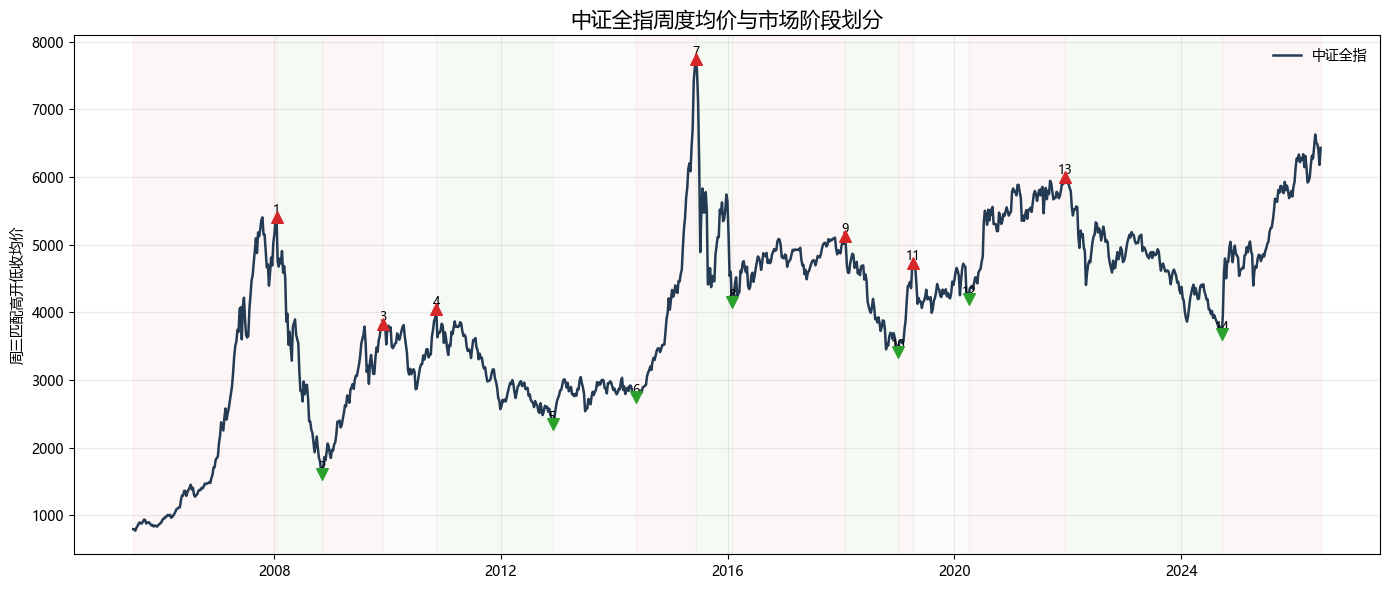

In [20]:
phase_df, turning_points = build_market_phase_table(weekly_price_wide)

phase_view = phase_df[[
    "phase_id", "phase_name", "start", "end", "market_regime", "regime_detail",
    "total_return", "annualized_vol", "max_drawdown", "event_note"
]].copy()

display(
    chinese_table(phase_view).style.format({
        "区间涨跌幅": "{:.1%}",
        "年化波动率": "{:.1%}",
        "最大回撤": "{:.1%}",
    })
)

fig = plot_market_turning_points(weekly_price_wide, phase_df, turning_points, save=True, close=False)
display(fig)
plt.close(fig)


## 1.3 市场阶段下的风格有效性

下面计算七类风格相对沪深300的周度超额收益，并按市场阶段汇总。折线图看长期累计效果，热力图看不同环境中的风格强弱。


,风格因子,风格指数名称,开始日期,结束日期,周数,缺失超额收益周数
0,价值,300价值,2005-07-06,2026-06-17,1094,1
1,成长,300成长,2005-07-06,2026-06-17,1094,1
2,红利,中证红利,2005-07-06,2026-06-17,1094,1
3,低波,300SNLV,2005-07-06,2026-06-17,1094,1
4,质量,盈利质量,2005-07-06,2026-06-17,1094,1
5,规模,中证500,2005-07-06,2026-06-17,1094,1
6,动量,300动量,2005-07-06,2026-06-17,1094,1


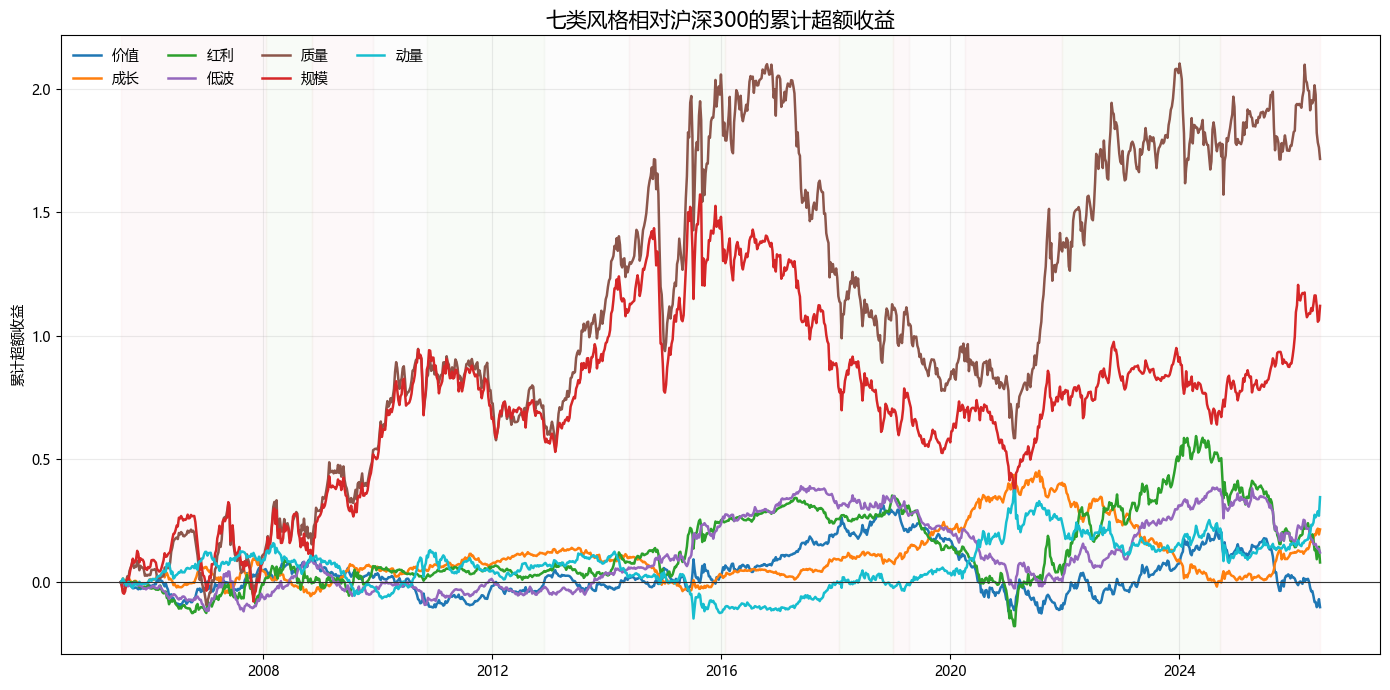

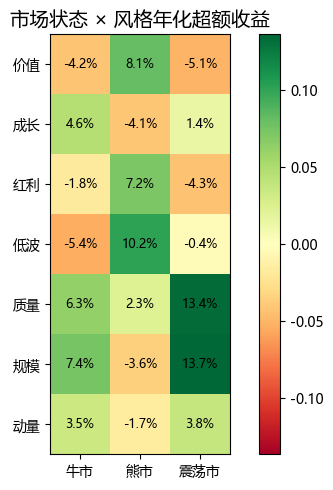

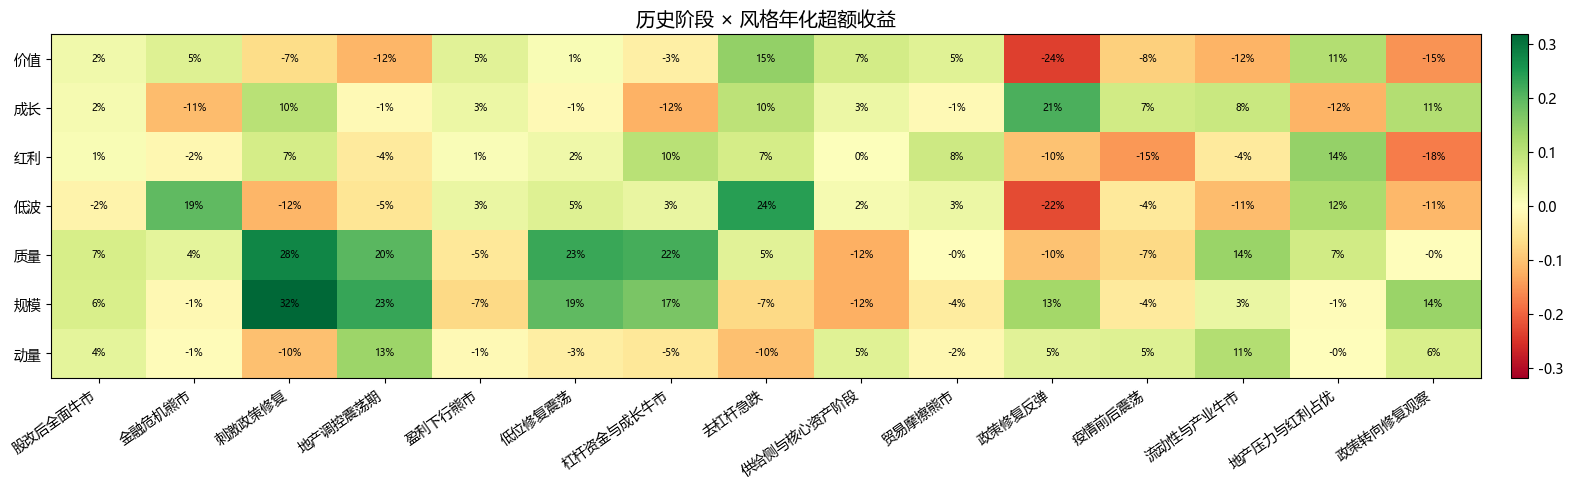

In [21]:
env_table = build_environment_table(weekly_price_wide, weekly_return_wide, rate_daily, phase_df)
panel = build_style_panel(weekly_return_wide, env_table)
summary = build_environment_summary(panel)

sample_check = (
    panel.groupby(["factor_cn", "style_index_name"], observed=True)
    .agg(start=("date", "min"), end=("date", "max"), weeks=("date", "size"), missing_excess=("primary_excess", lambda x: x.isna().sum()))
    .reset_index()
)
display(chinese_table(sample_check))

for fig in [
    plot_cumulative_excess(panel, phase_df, save=True, close=False),
    plot_market_regime_heatmap(summary, save=True, close=False),
    plot_phase_heatmap(summary, save=True, close=False),
]:
    if fig is not None:
        display(fig)
        plt.close(fig)


In [22]:
market_summary = summary[summary["environment_type"] == "市场状态"].copy()
market_summary_view = (
    market_summary.pivot(index="factor_cn", columns="environment_value", values="ann_excess_mean")
    .reindex(STYLE_ORDER)
    .rename_axis(index="风格因子", columns="市场状态")
)
cols = [col for col in ["牛市", "熊市", "震荡市"] if col in market_summary_view.columns]
display(market_summary_view[cols].style.format("{:.1%}"))

top_by_regime = (
    market_summary.sort_values(["environment_value", "ann_excess_mean"], ascending=[True, False])
    .groupby("environment_value")
    .head(3)[["environment_value", "factor_cn", "ann_excess_mean", "information_ratio", "win_rate"]]
)
display(chinese_table(top_by_regime).style.format({"年化超额收益": "{:.1%}", "信息比率": "{:.2f}", "胜率": "{:.1%}"}))


市场状态,牛市,熊市,震荡市
风格因子,,,
价值,-4.2%,8.1%,-5.1%
成长,4.6%,-4.1%,1.4%
红利,-1.8%,7.2%,-4.3%
低波,-5.4%,10.2%,-0.4%
质量,6.3%,2.3%,13.4%
规模,7.4%,-3.6%,13.7%
动量,3.5%,-1.7%,3.8%


,环境分类,风格因子,年化超额收益,信息比率,胜率
3,熊市,低波,10.2%,1.54,58.4%
0,熊市,价值,8.1%,0.90,56.0%
2,熊市,红利,7.2%,0.70,54.7%
12,牛市,规模,7.4%,0.51,55.1%
11,牛市,质量,6.3%,0.38,54.3%
8,牛市,成长,4.6%,0.73,53.0%
19,震荡市,规模,13.7%,1.10,59.3%
18,震荡市,质量,13.4%,1.05,61.0%
20,震荡市,动量,3.8%,0.53,55.4%


在熊市中，低波、价值和红利三种风格因子能取得不俗的表现，而成长和规模两种风格成为拖累；在震荡市中，规模和质量这两种风格因子表现突出，价值和红利回撤较大；在牛市中，规模和质量这两种风格因子表现尚可，价值和低波表现不佳，而成长因子有较高的信息比率，但相比熊市和震荡市，这些风格因子总体上并不能超越宽基更多，因此持有宽基也是一个不错的选择。


## 1.4 利率与波动环境

利率方向用10年期国债收益率13周变化划分，波动环境用中证全指26周年化波动率分位数划分。这个维度用于判断风格有效性的宏观背景。


利率方向,利率上行,利率下行,利率震荡
风格因子,,,
价值,-0.4%,3.9%,-4.2%
成长,1.5%,0.7%,1.2%
红利,-1.8%,1.6%,2.8%
低波,-1.5%,2.5%,1.1%
质量,-1.7%,1.2%,18.6%
规模,-4.6%,-0.9%,18.9%
动量,2.7%,1.7%,1.2%


波动环境,中波动,低波动,高波动
风格因子,,,
价值,-5.8%,5.5%,2.0%
成长,2.9%,-3.2%,3.1%
红利,-2.8%,4.9%,2.1%
低波,-3.7%,4.0%,4.0%
质量,8.5%,-3.9%,12.8%
规模,6.9%,-3.7%,9.3%
动量,3.2%,6.0%,-4.2%


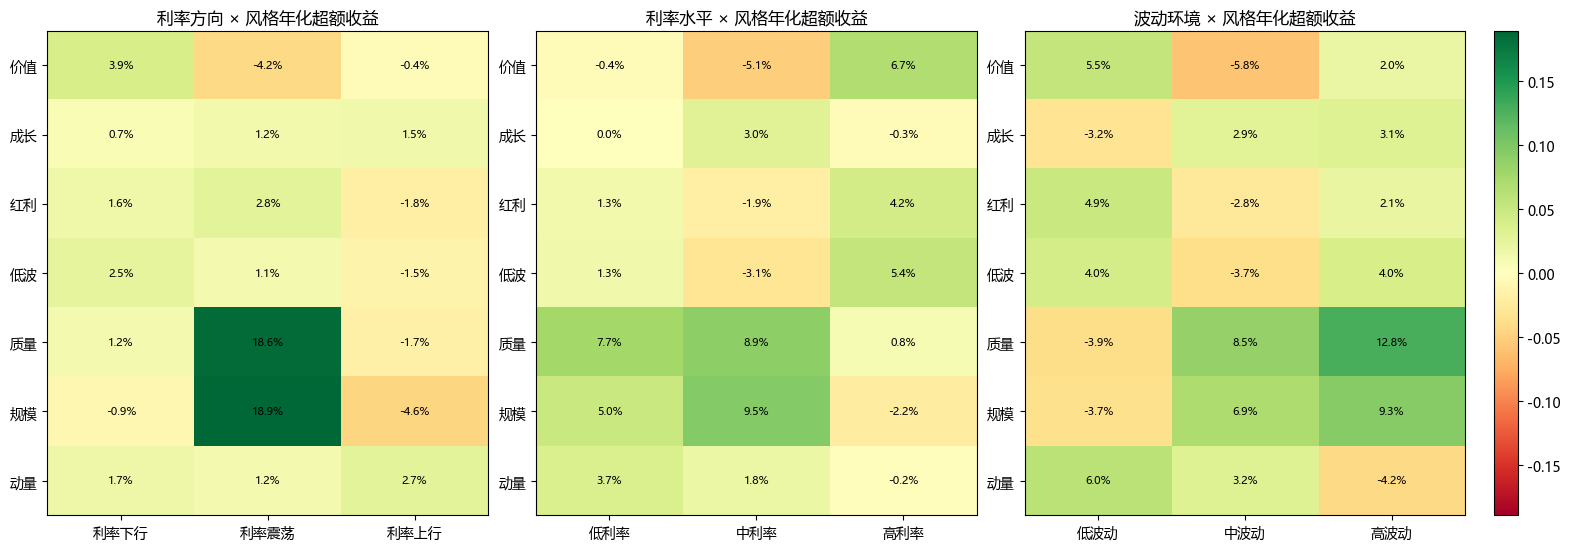

In [23]:
rate_summary = summary[summary["environment_type"].isin(["利率方向", "波动环境"])].copy()

rate_direction = (
    rate_summary[rate_summary["environment_type"] == "利率方向"]
    .pivot(index="factor_cn", columns="environment_value", values="ann_excess_mean")
    .reindex(STYLE_ORDER)
    .rename_axis(index="风格因子", columns="利率方向")
)
vol_env = (
    rate_summary[rate_summary["environment_type"] == "波动环境"]
    .pivot(index="factor_cn", columns="environment_value", values="ann_excess_mean")
    .reindex(STYLE_ORDER)
    .rename_axis(index="风格因子", columns="波动环境")
)

display(rate_direction.style.format("{:.1%}"))
display(vol_env.style.format("{:.1%}"))

fig = plot_rate_vol_environment_heatmap(summary, save=True, close=False)
if fig is not None:
    display(fig)
    plt.close(fig)


从市场波动环境维度评价，在中高波动环境下质量和规模这两种风格因子表现突出，在低波动环境下动量、价值和红利表现尚可。
从利率水平维度评价，在中低利率环境下质量和规模表现突出，在高利率环境下价值、红利和低波表现不俗。
（利率方向先不看了）


# 2. 行业属性

由于篇幅所限和数据获取便利性，本部分在大盘股范围内分析六个风格因子在行业维度的有效性，具体包括价值、成长、红利、低波、质量、动量。行业指数使用沪深300行业指数，重点观察不同行业相对沪深300的超额收益对风格暴露的敏感度。


## 2.1 行业数据覆盖与缺失处理

行业指数使用沪深300行业指数。周度价格按每周三观察点向前匹配最近有效交易日价格；指数尚未发布前保留为空，回归时自动剔除缺失样本。


In [24]:
industry_panel = build_industry_panel(weekly_return_wide, env_table)
industry_regression = build_industry_style_regression(industry_panel, panel)
industry_effectiveness = build_industry_factor_effectiveness(industry_panel, industry_regression)

industry_coverage = (
    industry_panel.groupby(["industry_name", "industry_code"], observed=True)
    .agg(
        start=("date", lambda x: x[industry_panel.loc[x.index, "industry_excess"].notna()].min()),
        end=("date", lambda x: x[industry_panel.loc[x.index, "industry_excess"].notna()].max()),
        valid_weeks=("industry_excess", lambda x: x.notna().sum()),
        missing_weeks=("industry_excess", lambda x: x.isna().sum()),
    )
    .reset_index()
)
display(chinese_table(industry_coverage))


,行业名称,行业代码,开始日期,结束日期,有效周数,缺失周数
0,300能源,000908.CSI,2005-07-13,2026-06-17,1093,1
1,300原材料,000909.CSI,2005-07-13,2026-06-17,1093,1
2,300工业,000910.CSI,2005-07-13,2026-06-17,1093,1
3,300可选消费,000911.CSI,2005-07-13,2026-06-17,1093,1
4,300主要消费,000912.CSI,2005-07-13,2026-06-17,1093,1
5,300医药卫生,000913.SH,2005-07-13,2026-06-17,1093,1
6,300信息技术,000915.CSI,2005-07-13,2026-06-17,1093,1
7,300通信服务,000916.CSI,2005-07-13,2026-06-17,1093,1
8,300公用事业,000917.CSI,2005-07-13,2026-06-17,1093,1
9,300房地产,000952.CSI,2005-07-13,2026-06-17,1093,1


## 2.2 行业对风格的回归敏感度

这里以行业相对沪深300的周度超额收益为 Y，以七类风格相对沪深300的周度超额收益为 X。回归系数越高，表示该行业在对应风格占优时越容易同步跑赢沪深300。R方表示七类风格对该行业超额收益的解释度，残差表示风格模型无法解释的年化波动。若某行业的残差较高，说明它还有更强的行业基本面或政策主题驱动。


风格因子,价值,成长,红利,低波,质量,动量,R方,残差
行业名称,,,,,,,,
300能源,0.48,-0.09,0.83,-0.13,-0.15,0.01,31.1%,15.7%
300原材料,-0.29,-0.04,0.62,-0.35,0.06,0.03,20.9%,12.8%
300工业,-0.29,-0.26,0.14,-0.15,0.16,-0.00,23.6%,8.8%
300可选消费,-0.37,-0.12,0.13,-0.00,0.15,0.01,16.3%,10.9%
300主要消费,-0.88,0.19,0.18,0.63,-0.15,0.24,12.2%,16.8%
300医药卫生,-1.04,0.28,0.08,0.64,0.16,0.16,27.6%,15.8%
300信息技术,-1.10,-0.30,-0.22,0.15,0.45,-0.18,46.2%,14.4%
300通信服务,-0.61,-0.57,-0.16,0.39,0.01,0.02,6.4%,21.3%
300公用事业,0.09,-0.38,0.36,0.71,0.05,0.08,34.0%,13.4%


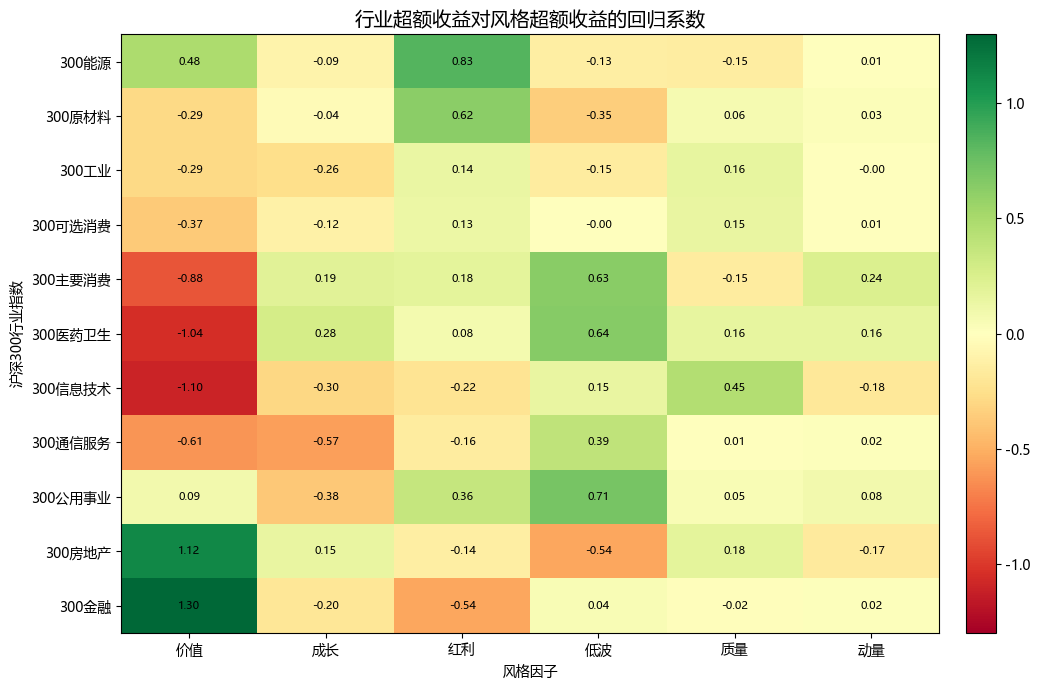

,行业名称,风格因子,回归系数,t值,p值
2,300能源,红利,0.83,12.58,0.0000
0,300能源,价值,0.48,5.65,0.0000
8,300原材料,红利,0.62,11.60,0.0000
10,300原材料,质量,0.06,1.77,0.0767
16,300工业,质量,0.16,6.52,0.0000
14,300工业,红利,0.14,3.71,0.0002
22,300可选消费,质量,0.15,4.94,0.0000
20,300可选消费,红利,0.13,2.81,0.0050
27,300主要消费,低波,0.63,6.67,0.0000
29,300主要消费,动量,0.24,3.98,0.0001


In [25]:
beta_matrix = (
    industry_regression.pivot(index="industry_name", columns="factor_cn", values="coef_beta")
    .reindex(index=INDUSTRY_ORDER, columns=CORE_STYLE_ORDER)
)
r2_series = industry_regression.groupby("industry_name", observed=True)["r_squared"].first().reindex(INDUSTRY_ORDER)
residual_series = industry_regression.groupby("industry_name", observed=True)["residual_ann_vol"].first().reindex(INDUSTRY_ORDER)

beta_table = beta_matrix.copy()
beta_table["R方"] = r2_series
beta_table["残差"] = residual_series
beta_table = beta_table.rename_axis(index="行业名称", columns="风格因子")

formatters = {factor: "{:.2f}" for factor in CORE_STYLE_ORDER}
formatters.update({"R方": "{:.1%}", "残差": "{:.1%}"})
display(beta_table.style.format(formatters))

fig = plot_industry_style_beta_heatmap(industry_regression, save=True, close=False)
display(fig)
plt.close(fig)

industry_top_style = (
    industry_regression.sort_values(["industry_name", "coef_beta"], ascending=[True, False])
    .groupby("industry_name", observed=True)
    .head(2)[["industry_name", "factor_cn", "coef_beta", "t_stat", "p_value"]]
)
display(chinese_table(industry_top_style).style.format({"回归系数": "{:.2f}", "t值": "{:.2f}", "p值": "{:.4f}"}))


从行业维度评价，房地产和金融的价值风格属性很强，医药卫生、信息技术和主要消费的成长属性相对价格属性更强；能源和原材料的红利风格属性较强，金融的红利风格属性较弱；公用事业、医药卫生、主要消费、通信服务的低波属性较强；信息技术、工业、可选消费的质量风格属性较强；主要消费和医药卫生的动量属性较强。


## 2.3 行业维度的因子有效性评价

除了看回归系数，还要看某个风格能否把行业明显分层。这里用高 beta 行业组合减低 beta 行业组合的收益差，评估风格在行业维度上的可操作性。


,风格因子,贝塔分化度,平均绝对t值,显著正向行业数,显著负向行业数,高贝塔行业,低贝塔行业,高低贝塔组合年化收益差,高低贝塔组合信息比率,高低贝塔组合胜率
0,价值,0.82,8.51,3,7,300能源、300房地产、300金融,300信息技术、300医药卫生、300主要消费,-4.5%,-0.20,46.1%
1,成长,0.26,2.60,1,5,300房地产、300主要消费、300医药卫生,300通信服务、300公用事业、300信息技术,0.7%,0.04,50.0%
2,红利,0.39,5.28,6,2,300公用事业、300原材料、300能源,300金融、300信息技术、300通信服务,-3.8%,-0.22,49.0%
3,低波,0.42,3.89,4,3,300主要消费、300医药卫生、300公用事业,300房地产、300原材料、300工业,2.7%,0.17,50.5%
4,质量,0.17,3.63,5,2,300医药卫生、300房地产、300信息技术,300主要消费、300能源、300金融,-0.4%,-0.03,49.0%
5,动量,0.12,1.44,2,2,300公用事业、300医药卫生、300主要消费,300信息技术、300房地产、300工业,2.0%,0.14,51.3%


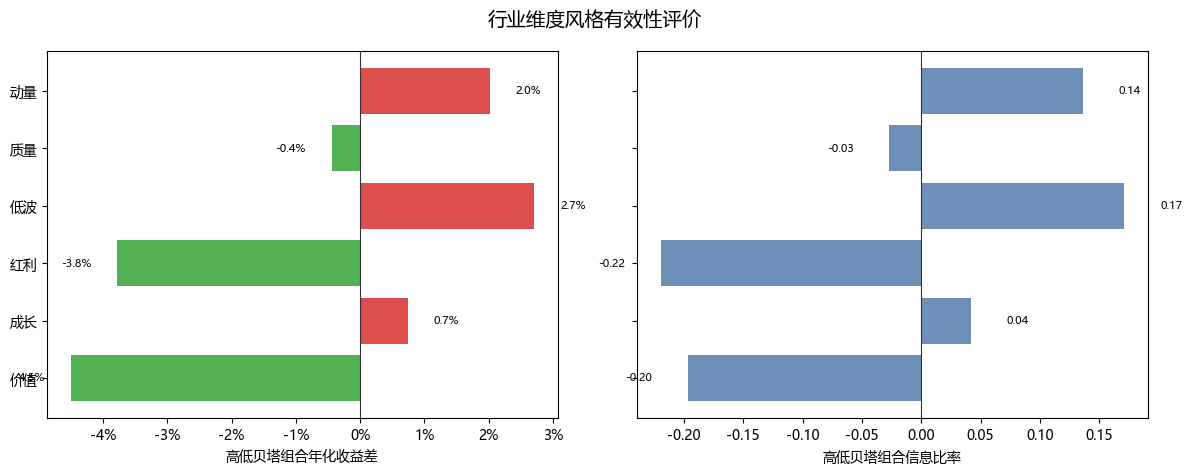

In [26]:
effectiveness_view = industry_effectiveness[[
    "factor_cn",
    "beta_dispersion",
    "avg_abs_t",
    "significant_positive_industries",
    "significant_negative_industries",
    "high_beta_industries",
    "low_beta_industries",
    "high_minus_low_ann_return",
    "high_minus_low_ir",
    "high_minus_low_win_rate",
]].copy()

display(
    chinese_table(effectiveness_view).style.format({
        "贝塔分化度": "{:.2f}",
        "平均绝对t值": "{:.2f}",
        "高低贝塔组合年化收益差": "{:.1%}",
        "高低贝塔组合信息比率": "{:.2f}",
        "高低贝塔组合胜率": "{:.1%}",
    })
)

fig = plot_factor_effectiveness_bars(industry_effectiveness, "行业维度风格有效性评价", "industry_factor_effectiveness_bars.png", save=True, close=False)
if fig is not None:
    display(fig)
    plt.close(fig)


价值和红利的beta分化度较高，说明能源、地产、金融、公用事业等行业确实带有明显价值/红利属性，但高低贝塔组合收益差为负，说明高价值/高红利行业在样本期内并没有稳定带来超额收益。相对更可用的是低波和动量：低波高贝塔行业集中在主要消费、医药、公用事业，年化收益差约2.7%、IR0.17；动量收益差约2.0%、IR0.14、胜率51.3%。整体看，行业风格有效性存在，但强度不高。

# 3. 企业生命周期

由于篇幅所限和数据获取便利性，且生命周期代理指数很容易天然带有市值差异，本部分仍只分析六个风格因子，具体包括价值、成长、红利、低波、质量、动量。企业生命周期划分为初创期、成长期、成熟期、调整期、衰退期；实证代理中，北证50代表初创期，创业板50代表成长期，中证A50代表成熟期，上国改革代表调整期。衰退期缺少稳定的可投资指数代理，暂不进入回归表。


## 3.1 生命周期代理指数与数据覆盖

四个代理指数的开始时间不同。周度价格按每周三观察点向前匹配最近有效交易日价格；指数尚无数据的区间自然留空，累计超额收益曲线在这些区间也留空。


,企业生命周期阶段,生命周期代理指数,生命周期指数代码,开始日期,结束日期,有效周数,缺失周数
0,初创期,北证50,899050.BJ,2022-05-11,2026-06-17,215,879
1,成长期,创业板50,399673.SZ,2010-06-09,2026-06-17,837,257
2,成熟期,中证A50,930050.CSI,2015-01-07,2026-06-17,598,496
3,调整期,上国改革,H50052.CSI,2014-04-09,2026-06-17,637,457


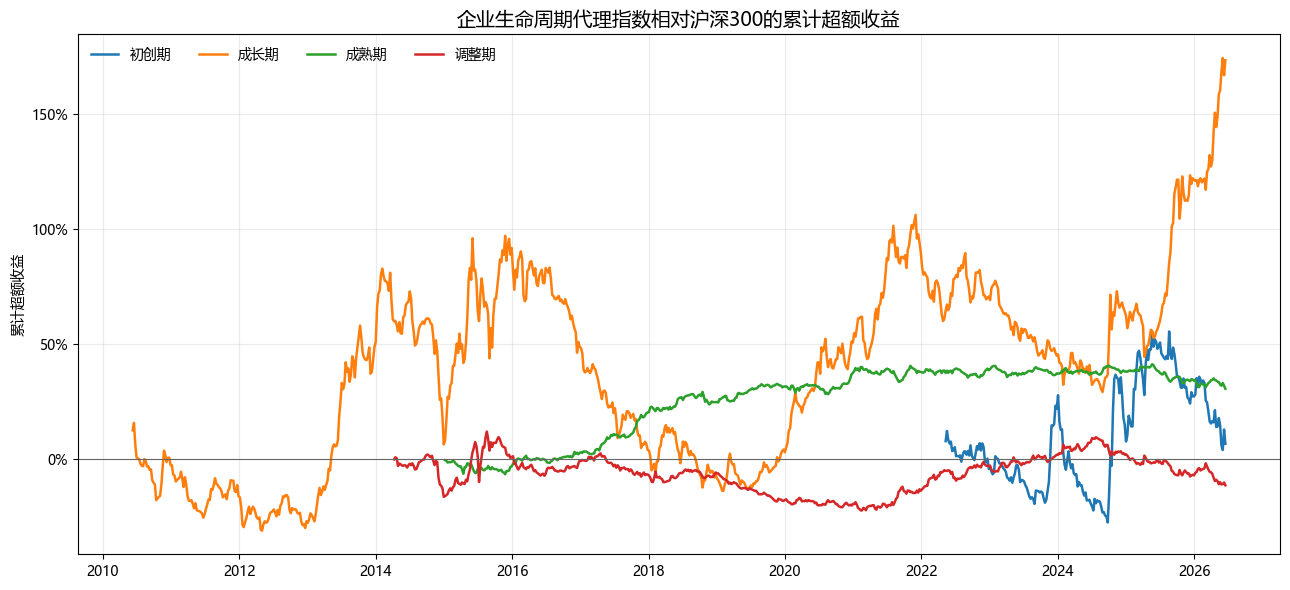

In [28]:
lifecycle_panel = build_lifecycle_panel(weekly_return_wide, env_table)
lifecycle_regression = build_lifecycle_style_regression(lifecycle_panel, panel)
lifecycle_effectiveness = build_lifecycle_factor_effectiveness(lifecycle_panel, lifecycle_regression)

save_core_tables(
    daily_long,
    rate_daily,
    weekly_long,
    weekly_price_wide,
    weekly_return_wide,
    phase_df,
    turning_points,
    env_table,
    panel,
    summary,
    industry_panel,
    industry_regression,
    industry_effectiveness,
    lifecycle_panel,
    lifecycle_regression,
    lifecycle_effectiveness,
)

lifecycle_coverage = (
    lifecycle_panel.groupby(["lifecycle_stage", "lifecycle_index_name", "lifecycle_code"], observed=True)
    .agg(
        start=("date", lambda x: x[lifecycle_panel.loc[x.index, "lifecycle_excess"].notna()].min()),
        end=("date", lambda x: x[lifecycle_panel.loc[x.index, "lifecycle_excess"].notna()].max()),
        valid_weeks=("lifecycle_excess", lambda x: x.notna().sum()),
        missing_weeks=("lifecycle_excess", lambda x: x.isna().sum()),
    )
    .reset_index()
)
display(chinese_table(lifecycle_coverage))

fig = plot_lifecycle_cumulative_excess(lifecycle_panel, save=True, close=False)
display(fig)
plt.close(fig)


## 3.2 生命周期阶段对风格的回归判断

以生命周期代理指数相对沪深300的周度超额收益为 Y，以六个风格因子相对沪深300的周度超额收益为 X，观察不同生命周期代理对风格暴露的敏感度。


风格因子,价值,成长,红利,低波,质量,动量,R方,残差
企业生命周期阶段,,,,,,,,
初创期,0.13,-0.19,-0.60,-0.44,0.97,-0.91,21.7%,28.7%
成长期,-1.04,0.26,-0.25,-0.13,0.58,-0.15,53.8%,14.8%
成熟期,0.12,0.23,-0.00,-0.05,-0.06,0.06,21.6%,3.9%
调整期,-0.21,-0.51,0.36,-0.15,0.09,0.09,50.1%,6.4%


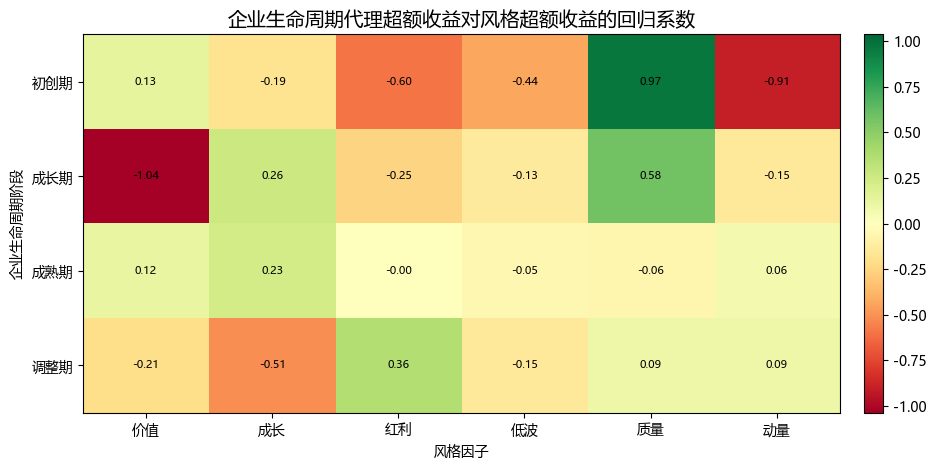

,企业生命周期阶段,风格因子,回归系数,t值,p值
4,初创期,质量,0.97,5.53,0.0000
0,初创期,价值,0.13,0.29,0.7739
10,成长期,质量,0.58,11.96,0.0000
7,成长期,成长,0.26,2.39,0.0167
13,成熟期,成长,0.23,6.82,0.0000
12,成熟期,价值,0.12,4.37,0.0000
20,调整期,红利,0.36,9.67,0.0000
22,调整期,质量,0.09,4.10,0.0000


In [29]:
lifecycle_beta_matrix = (
    lifecycle_regression.pivot(index="lifecycle_stage", columns="factor_cn", values="coef_beta")
    .reindex(index=LIFECYCLE_ORDER, columns=CORE_STYLE_ORDER)
)
lifecycle_r2 = lifecycle_regression.groupby("lifecycle_stage", observed=True)["r_squared"].first().reindex(LIFECYCLE_ORDER)
lifecycle_residual = lifecycle_regression.groupby("lifecycle_stage", observed=True)["residual_ann_vol"].first().reindex(LIFECYCLE_ORDER)

lifecycle_beta_table = lifecycle_beta_matrix.copy()
lifecycle_beta_table["R方"] = lifecycle_r2
lifecycle_beta_table["残差"] = lifecycle_residual
lifecycle_beta_table = lifecycle_beta_table.rename_axis(index="企业生命周期阶段", columns="风格因子")

formatters = {factor: "{:.2f}" for factor in CORE_STYLE_ORDER}
formatters.update({"R方": "{:.1%}", "残差": "{:.1%}"})
display(lifecycle_beta_table.style.format(formatters))

fig = plot_lifecycle_style_beta_heatmap(lifecycle_regression, save=True, close=False)
display(fig)
plt.close(fig)

lifecycle_top_style = (
    lifecycle_regression.sort_values(["lifecycle_stage", "coef_beta"], ascending=[True, False])
    .groupby("lifecycle_stage", observed=True)
    .head(2)[["lifecycle_stage", "factor_cn", "coef_beta", "t_stat", "p_value"]]
)
display(chinese_table(lifecycle_top_style).style.format({"回归系数": "{:.2f}", "t值": "{:.2f}", "p值": "{:.4f}"}))


初创期对质量因子最敏感，质量beta接近0.97，同时对红利、低波、动量为负；成长期对成长和质量为正，但对价值暴露显著为负；成熟期各项beta更接近中性，这可能是因为沪深300跟中证A50相似，主要由稳健的大盘核心资产构成；调整期则明显偏红利，红利beta约0.36，同时对成长为负，不过这个结果受到本研究使用改革国企指数作为调整期代理的影响，国企通常具有红利强、成长弱的特点，因此可能有所偏误。简言之，越偏早期和成长阶段，越依赖质量、成长等盈利弹性和基本面筛选；越偏调整修复阶段，越容易体现红利和现金流属性。

## 3.3 生命周期维度的风格有效性评价

除了看回归系数，还比较高贝塔生命周期阶段和低贝塔生命周期阶段的收益差，用来判断某个风格是否能形成阶段区分。


,风格因子,贝塔分化度,平均绝对t值,显著正向生命周期阶段数,显著负向生命周期阶段数,高贝塔生命周期阶段,低贝塔生命周期阶段,高低贝塔组合年化收益差,高低贝塔组合信息比率,高低贝塔组合胜率
0,价值,0.55,5.06,1,2,初创期,成长期,-8.1%,-0.26,42.8%
1,成长,0.37,4.87,2,1,成长期,调整期,7.0%,0.32,50.1%
2,红利,0.40,3.72,1,1,调整期,初创期,-7.9%,-0.23,59.1%
3,低波,0.17,1.86,0,1,成熟期,初创期,-7.7%,-0.24,60.5%
4,质量,0.47,6.43,3,1,初创期,成熟期,7.7%,0.24,39.1%
5,动量,0.47,3.42,2,2,调整期,初创期,-7.9%,-0.23,59.1%


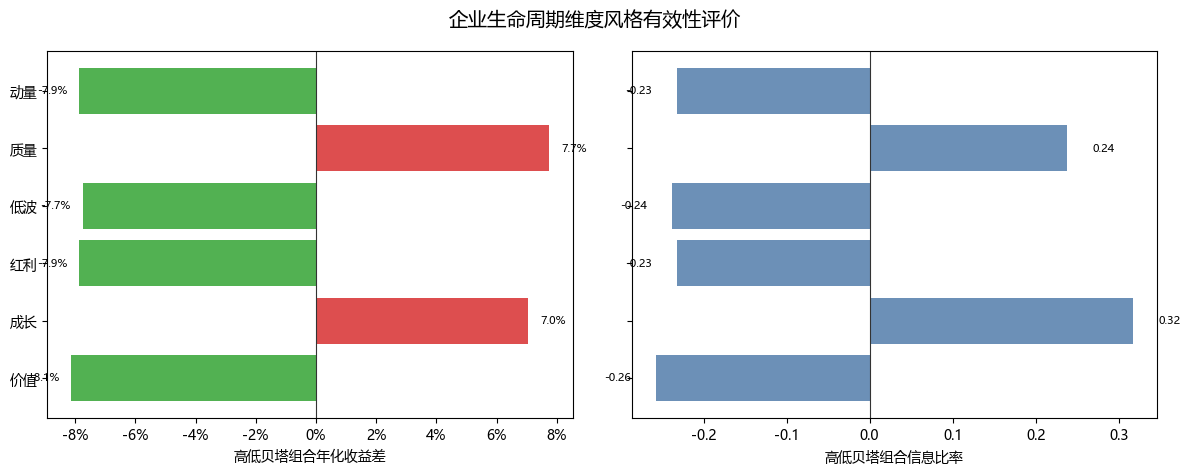

In [30]:
lifecycle_effectiveness_view = lifecycle_effectiveness[[
    "factor_cn",
    "beta_dispersion",
    "avg_abs_t",
    "significant_positive_lifecycle_stages",
    "significant_negative_lifecycle_stages",
    "high_beta_lifecycle_stages",
    "low_beta_lifecycle_stages",
    "high_minus_low_ann_return",
    "high_minus_low_ir",
    "high_minus_low_win_rate",
]].copy()

display(
    chinese_table(lifecycle_effectiveness_view).style.format({
        "贝塔分化度": "{:.2f}",
        "平均绝对t值": "{:.2f}",
        "高低贝塔组合年化收益差": "{:.1%}",
        "高低贝塔组合信息比率": "{:.2f}",
        "高低贝塔组合胜率": "{:.1%}",
    })
)

fig = plot_factor_effectiveness_bars(lifecycle_effectiveness, "企业生命周期维度风格有效性评价", "lifecycle_factor_effectiveness_bars.png", save=True, close=False)
if fig is not None:
    display(fig)
    plt.close(fig)


从生命周期维度评价，有正向区分效果的是成长和质量。成长因子的高低贝塔组合年化收益差约7.0%，信息比率0.32，高贝塔阶段是成长期，低贝塔阶段是调整期；质量因子年化收益差约7.7%，信息比率0.24，高贝塔阶段是初创期，低贝塔阶段是成熟期。
